# Titanic Survival Prediction

This project aims to predict passenger survival on the Titanic dataset using machine learning techniques.

The workflow includes:

- Data Cleaning
- Feature Engineering
- Model Comparison
- Hyperparameter Tuning
- Feature Importance Analysis
- Model Evaluation

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## Data Loading

*The Titanic dataset is loaded and inspected to understand its structure and available features*.

In [2]:
df=pd.read_csv("titanic.csv")
df[:5]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Handling Missing Values

*Missing values can negatively affect model performance.*

*The Age feature is imputed using the median age of passengers grouped by passenger class and gender.*

In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

most_common_embarked = df['Embarked'].mode()[0]

df['Embarked'] = df['Embarked'].fillna(most_common_embarked)

df.Age

#df.isnull().sum()

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    21.5
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.112424,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.304424,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,21.500000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Feature Engineering

Additional features are created to improve model performance:

- *Title extracted from passenger names*
- *HasCabin indicating cabin availability*
- *FamilySize representing family members aboard*

In [6]:
import pandas as pd
import re 

df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

print(df[['Name', 'Title']].head())


print(df['Title'].value_counts())
df=df.drop("Name",axis=1)
df

                                                Name Title
0                            Braund, Mr. Owen Harris    Mr
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs
2                             Heikkinen, Miss. Laina  Miss
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs
4                           Allen, Mr. William Henry    Mr
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


<>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\NPC\AppData\Local\Temp\ipykernel_13532\4000703031.py:4: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,211536,13.0000,NaN,S,Rev
887,888,1,1,female,19.0,0,0,112053,30.0000,B42,S,Miss
888,889,0,3,female,21.5,1,2,W./C. 6607,23.4500,NaN,S,Miss
889,890,1,1,male,26.0,0,0,111369,30.0000,C148,C,Mr


In [7]:
df=df.drop("PassengerId",axis=1)
df=df.drop("Ticket",axis=1)
df["HasCabin"] = df["Cabin"].notna().astype(int)
df=df.drop("Cabin",axis=1)
df["FamilySize"] = df.SibSp + df.Parch + 1
df=df.drop("SibSp",axis=1)
df=df.drop("Parch",axis=1)

target=df.pop("Survived")
df["Survived"]=target

df[:5]

,Pclass,Sex,Age,Fare,Embarked,Title,HasCabin,FamilySize,Survived
0,3,male,22.0,7.2500,S,Mr,0,2,0
1,1,female,38.0,71.2833,C,Mrs,1,2,1
2,3,female,26.0,7.9250,S,Miss,0,1,1
3,1,female,35.0,53.1000,S,Mrs,1,2,1
4,3,male,35.0,8.0500,S,Mr,0,1,0


In [8]:
X=df.drop("Survived",axis=1).values
y=df.Survived.values
X[:5]

array([[3, 'male', 22.0, 7.25, 'S', 'Mr', 0, 2],
       [1, 'female', 38.0, 71.2833, 'C', 'Mrs', 1, 2],
       [3, 'female', 26.0, 7.925, 'S', 'Miss', 0, 1],
       [1, 'female', 35.0, 53.1, 'S', 'Mrs', 1, 2],
       [3, 'male', 35.0, 8.05, 'S', 'Mr', 0, 1]], dtype=object)

## Encoding Categorical Features

*Machine learning models require numerical inputs*.

*Categorical variables are converted into numerical representations using Label Encoding*.

In [9]:
from sklearn.preprocessing import LabelEncoder
le_sex=LabelEncoder()
X[:,1]=le_sex.fit_transform(X[:,1])
le_embarked=LabelEncoder()
X[:,4]=le_embarked.fit_transform(X[:,4])
le_titel=LabelEncoder()
X[:,5] = le_titel.fit_transform(X[:,5])
X[:5]

array([[3, 1, 22.0, 7.25, 2, 12, 0, 2],
       [1, 0, 38.0, 71.2833, 0, 13, 1, 2],
       [3, 0, 26.0, 7.925, 2, 9, 0, 1],
       [1, 0, 35.0, 53.1, 2, 13, 1, 2],
       [3, 1, 35.0, 8.05, 2, 12, 0, 1]], dtype=object)

## Model Comparison using Cross Validation

*Several machine learning algorithms are evaluated using 5-Fold Cross Validation*.

*This helps identify which model is most suitable for the dataset before performing hyperparameter tuning*.

In [10]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
models={"Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "KNN": KNeighborsClassifier()
}
for name,model in models.items():
    Score = cross_val_score(model,X,y,cv=5).mean()
    print(f"{name} : {Score}")

Decision Tree : 0.7767057937354843
Random Forest : 0.8069801016885318
KNN : 0.7093653882367711


## Train-Test Split

*The dataset is divided into training and testing sets*.

*The training set is used for model development, while the testing set is reserved for final evaluation*.

In [11]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(X,y,random_state=42)

## Hyperparameter Tuning - Decision Tree

*GridSearchCV is used to find the optimal maximum depth for the Decision Tree model using 5-Fold Cross Validation*.

In [12]:
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth": range(1,11)
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt.fit(x_train, y_train)

print("Best Params:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

Best Params: {'max_depth': 3}
Best CV Score: 0.8173717876781506


## Hyperparameter Tuning - Random Forest

*GridSearchCV is applied to determine the best maximum depth for the Random Forest model*.

In [13]:
params = {
    "max_depth": range(1,11)
}

grid_rf = GridSearchCV(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

print("Best Params:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Params: {'max_depth': 5}
Best CV Score: 0.8338458085512288


## Cross Validation Performance

*The following plot shows the average cross-validation accuracy for different values of max_depth*.

*The highlighted points indicate the best-performing configurations*.

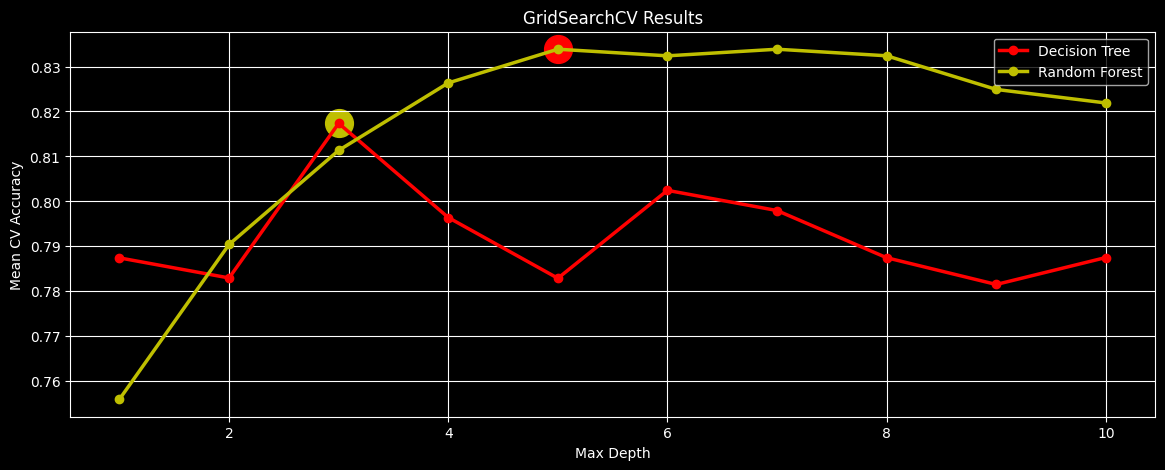

In [14]:
dt_scores = grid_dt.cv_results_["mean_test_score"]
rf_scores = grid_rf.cv_results_["mean_test_score"]

depths = list(range(1,11))
plt.figure(figsize=(14,5))

plt.plot(depths, dt_scores, marker="o", label="Decision Tree", color="r",linewidth=2.5)
plt.plot(depths, rf_scores, marker="o", label="Random Forest",color="y",linewidth=2.5)
plt.scatter(grid_dt.best_params_["max_depth"],grid_dt.best_score_ , s=400 ,color="y")
plt.scatter(grid_rf.best_params_["max_depth"] , grid_rf.best_score_ ,s=400 ,color="r")
plt.xlabel("Max Depth")
plt.ylabel("Mean CV Accuracy")
plt.title("GridSearchCV Results")
plt.legend()
plt.grid(True)
plt.show()

## Feature Importance Analysis

*Feature importance scores are used to identify which variables contribute the most to survival prediction*.

*The results are compared between Decision Tree and Random Forest models*.

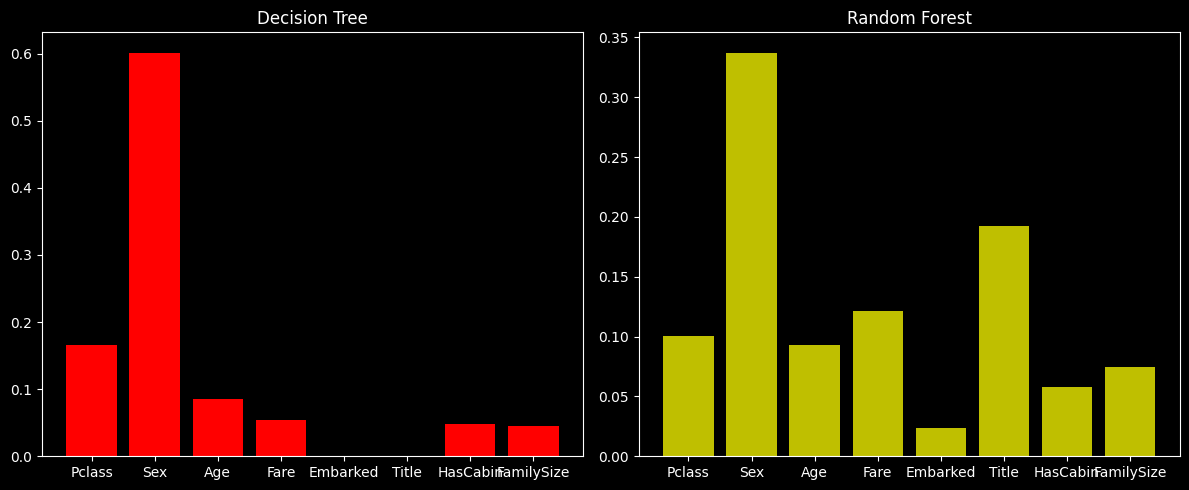

In [15]:
best_dt_model=grid_dt.best_estimator_
best_rf_model=grid_rf.best_estimator_
fig, ax = plt.subplots(1, 2, figsize=(12,5))

features = [
    "Pclass", "Sex", "Age", "Fare",
    "Embarked", "Title", "HasCabin", "FamilySize"
]

ax[0].bar(features, best_dt_model.feature_importances_,color="r")
ax[0].set_title("Decision Tree")

ax[1].bar(features, best_rf_model.feature_importances_,color="y")
ax[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

## Decision Tree Visualization

*The structure of the best Decision Tree model is visualized to understand the decision-making process*.

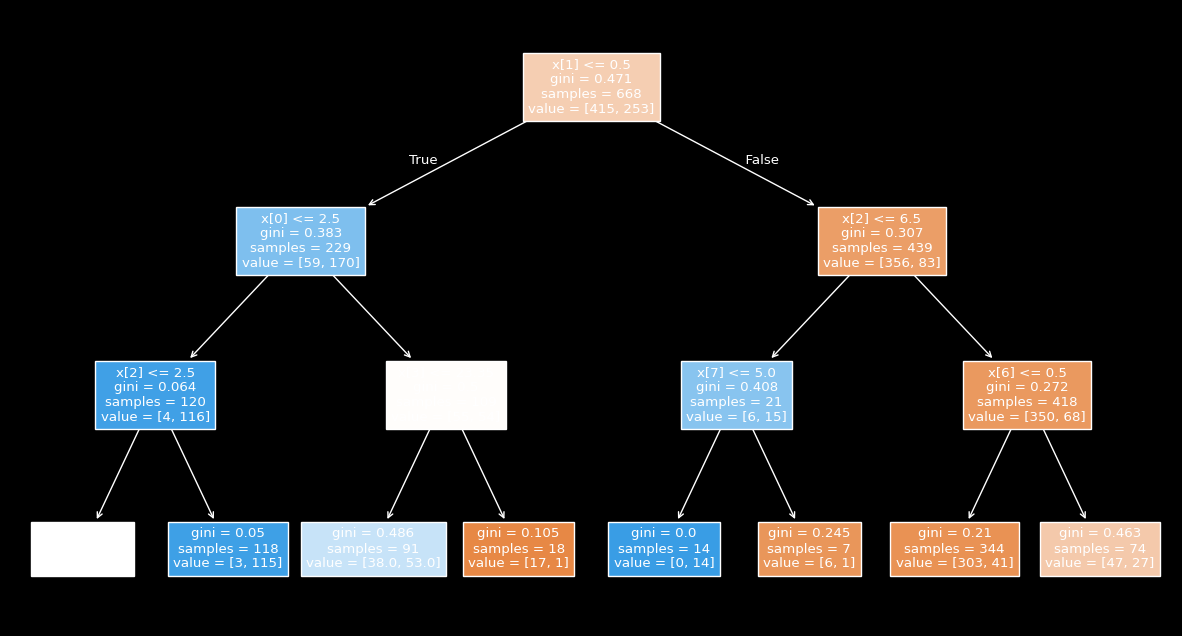

In [16]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,8))
plot_tree(best_dt_model,filled=True)
plt.show()

## Random Forest Tree Visualization

*Random Forest is an ensemble learning method that consists of multiple decision trees*.

*The visualization below shows a single tree extracted from the best Random Forest model selected by GridSearchCV*.

*This tree is one of many trees used by the ensemble to make predictions. The final prediction of the Random Forest is obtained by aggregating the predictions of all trees rather than relying on a single tree*.

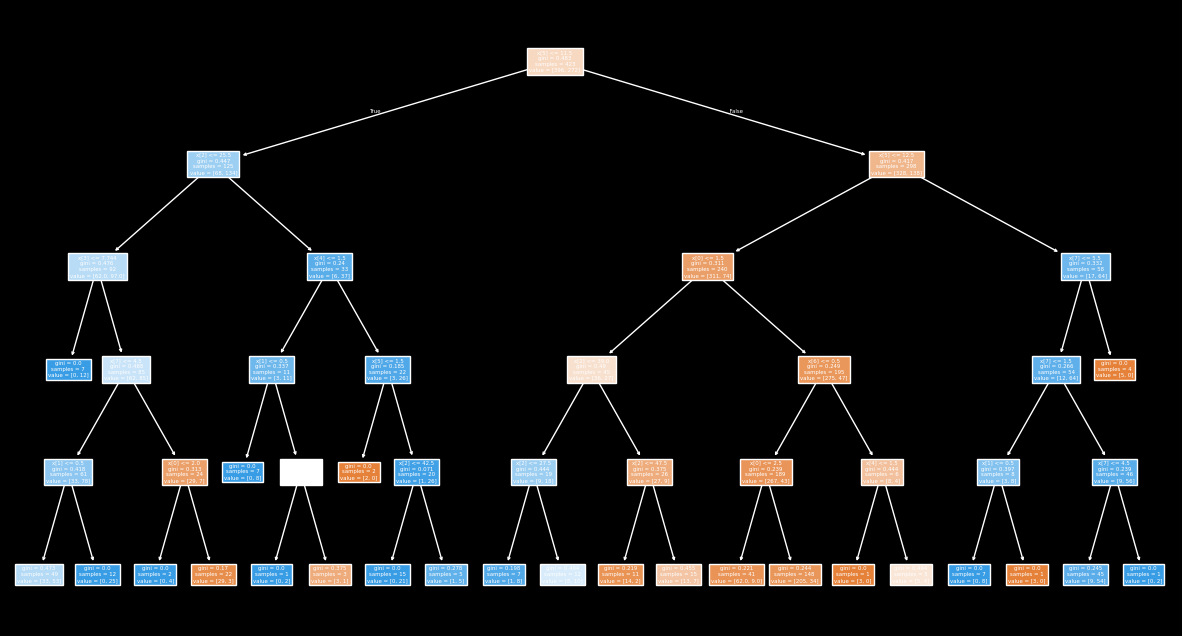

In [17]:
plt.figure(figsize=(15,8))
tree0=best_rf_model.estimators_[0]
plot_tree(tree0,filled=True)
plt.show()

## Confusion Matrix

*The confusion matrix provides a detailed breakdown of correct and incorrect predictions*.

*It helps evaluate model performance beyond overall accuracy*.

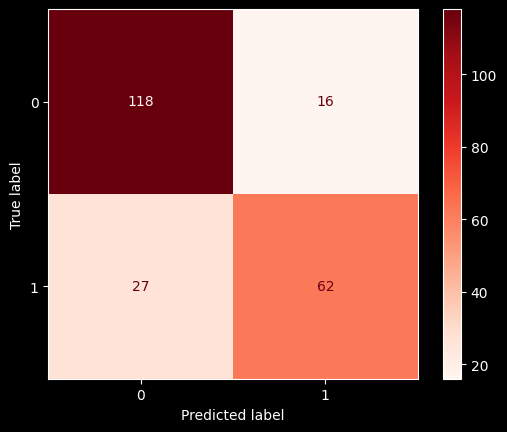

[[118  16]
 [ 27  62]]


In [18]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
ConfusionMatrixDisplay.from_predictions(y_test,best_dt_model.predict(x_test),cmap="Reds")
plt.show()

CM=confusion_matrix(y_test,best_dt_model.predict(x_test))
print(CM)

## Classification Report

*Precision, Recall, and F1-Score are calculated to provide a comprehensive evaluation of the model's predictive performance*.

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, best_dt_model.predict(x_test)))
print(classification_report(y_test, best_rf_model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.81      0.88      0.85       134
           1       0.79      0.70      0.74        89

    accuracy                           0.81       223
   macro avg       0.80      0.79      0.79       223
weighted avg       0.81      0.81      0.80       223

              precision    recall  f1-score   support

           0       0.83      0.88      0.86       134
           1       0.80      0.73      0.76        89

    accuracy                           0.82       223
   macro avg       0.82      0.81      0.81       223
weighted avg       0.82      0.82      0.82       223



## Model Serialization

*The best-performing Random Forest model is saved using Joblib*.

*This allows the trained model to be reused later without retraining, making deployment and future predictions more efficient*.

In [20]:
import joblib

joblib.dump(best_rf_model, "best_random_forest.pkl")
joblib.dump(best_dt_model, "best_decision_tree.pkl")

['best_decision_tree.pkl']

## Understanding Precision and Recall
### Precision

Precision answers the following question:

> Out of all passengers predicted as survivors by the model, how many actually survived?

From the confusion matrix:

- Predicted survivors = 16 + 62 = 78
- Correctly predicted survivors = 62

Therefore:

Precision = 62 / 78 ≈ 0.79

**Interpretation:**

When the model predicts that a passenger survived, it is correct about **79% of the time**.

---

### Recall

Recall answers the following question:

> Out of all passengers who actually survived, how many were correctly identified by the model?

From the confusion matrix:

- Actual survivors = 27 + 62 = 89
- Correctly identified survivors = 62

Therefore:

Recall = 62 / 89 ≈ 0.70

**Interpretation:**

The model successfully identifies about **70% of all survivors**, but misses approximately **30%** of them.

---

### Difference Between Precision and Recall

- **Precision** measures the reliability of positive predictions.
- **Recall** measures the model's ability to find all positive cases.

In other words:

- High **Precision** means: *"When the model says a passenger survived, it is usually correct."*
- High **Recall** means: *"The model finds most of the passengers who actually survived."*

In [21]:
from sklearn.metrics import accuracy_score
print("Decision Tree Accuracy :" , accuracy_score(y_test,best_dt_model.predict(x_test)))
print("Random Forest Accuracy :" , accuracy_score(y_test,best_rf_model.predict(x_test)))

Decision Tree Accuracy : 0.8071748878923767
Random Forest Accuracy : 0.820627802690583


## Conclusion

Several machine learning models were evaluated using 5-Fold Cross Validation to identify the most suitable algorithm for the Titanic dataset.

After comparing multiple models, Decision Tree and Random Forest were further optimized using GridSearchCV to determine the best hyperparameter configuration.

The final evaluation on the test set produced the following results:

- Decision Tree Accuracy: **80.72%**
- Random Forest Accuracy: **82.06%**

Feature importance analysis revealed that variables such as Sex, Title, Fare, and Passenger Class were among the most influential factors affecting survival prediction.

The Random Forest model achieved the highest accuracy and demonstrated more robust performance than a single Decision Tree. This result highlights the advantage of ensemble learning, where multiple trees work together to reduce variance and improve generalization.

Overall, Random Forest proved to be the most effective model for predicting passenger survival on the Titanic dataset.